# Kampala Air Quality and TB Analysis - Simplified Pipeline

In [54]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from datetime import date
from scipy import stats
from sklearn.impute import SimpleImputer

import sys
sys.path.append('./src')

from simplified_data_processor import SimplifiedDataProcessor
from intervention_simulator import InterventionSimulator
from time_series_modeler import TimeSeriesModeler
from visualizer import Visualizer
from report_generator import ReportGenerator

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All modules imported successfully")

import warnings
warnings.filterwarnings('ignore')


✓ All modules imported successfully


In [42]:
resp_df = pd.read_excel('data/Data RTI DHIS2.xls', sheet_name='MOH - Uganda, Kampala', header=2)
clim_df = pd.read_csv('data/epi_weekly_climate data_kampala.csv')
plo_df = pd.read_csv('data/kampala_weekly_PM2.5 climate data averaged_across_sites.csv')

main_df = pd.merge(
    clim_df,
    plo_df,
    left_on=['epi_year', 'epi_week'],
    right_on=['year', 'week'],
    how='inner'
)

drop_cols = ['year', 'week']
main_df.drop(columns=drop_cols, inplace=True)

# Function to get the last day (Sunday) of each ISO week
def get_last_day_of_week(year, week):
    return date.fromisocalendar(int(year), int(week), 7)

# Apply function to create a proper date column
main_df['date'] = main_df.apply(
    lambda row: get_last_day_of_week(row['epi_year'], row['epi_week']),
    axis=1
)

main_df['date'] = pd.to_datetime(main_df['date'])   # ensure datetime dtype

# Extract the last date (Sunday) from periodname
resp_df['date'] = resp_df['periodname'].str.extract(r'-\s*(\d{4}-\d{2}-\d{2})')
resp_df['date'] = pd.to_datetime(resp_df['date'], errors='coerce')

# Keep ALL columns (not just TB)
resp_df = resp_df.drop(columns=['periodname'])  # drop only the text period column


In [43]:

# --- Merge climate + TB + other health indicators ---
merged_df = pd.merge(main_df, resp_df, on='date', how='inner')


# Rename climate columns to match processor expectations
rename_map = {
    'weekly_pm25_avg': 'pm2_5',
    'weekly_temp_avg': 'avgtemp',
    'weekly_humidity_avg': 'avghumidity',
    'Pulmonary TB cases': 'TB',
    'Avg_Temp(C)': 'avgtemp_sat',
    'AvgWindspeed(m/s)': 'windspeed',
    'AvgPrecipitation(mm/day)': 'precip',
    'AvgRelative_Humidity(%)': 'humidity_sat',
    'ILI Cases': 'ILI',
    'ILD deaths': 'ILD_deaths',
    'Severe pneumonia under 5 Cases': 'pneumonia_u5',
    'Severe pneumonia under 5 deaths': 'pneumonia_u5_deaths',
    'SARI Cases': 'SARI',
    'SARI Deaths': 'SARI_deaths'
}

merged_df.rename(columns=rename_map, inplace=True)

In [44]:
# Select the columns you want to impute
cols_to_impute = ['pm2_5', 'avgtemp', 'avghumidity', 'TB']

imputer = SimpleImputer(strategy='mean')  # or 'median', 'most_frequent'
merged_df[cols_to_impute] = imputer.fit_transform(merged_df[cols_to_impute])

# Save merged dataset
merged_df.to_csv('data/merged_climate_tb_data.csv', index=False)

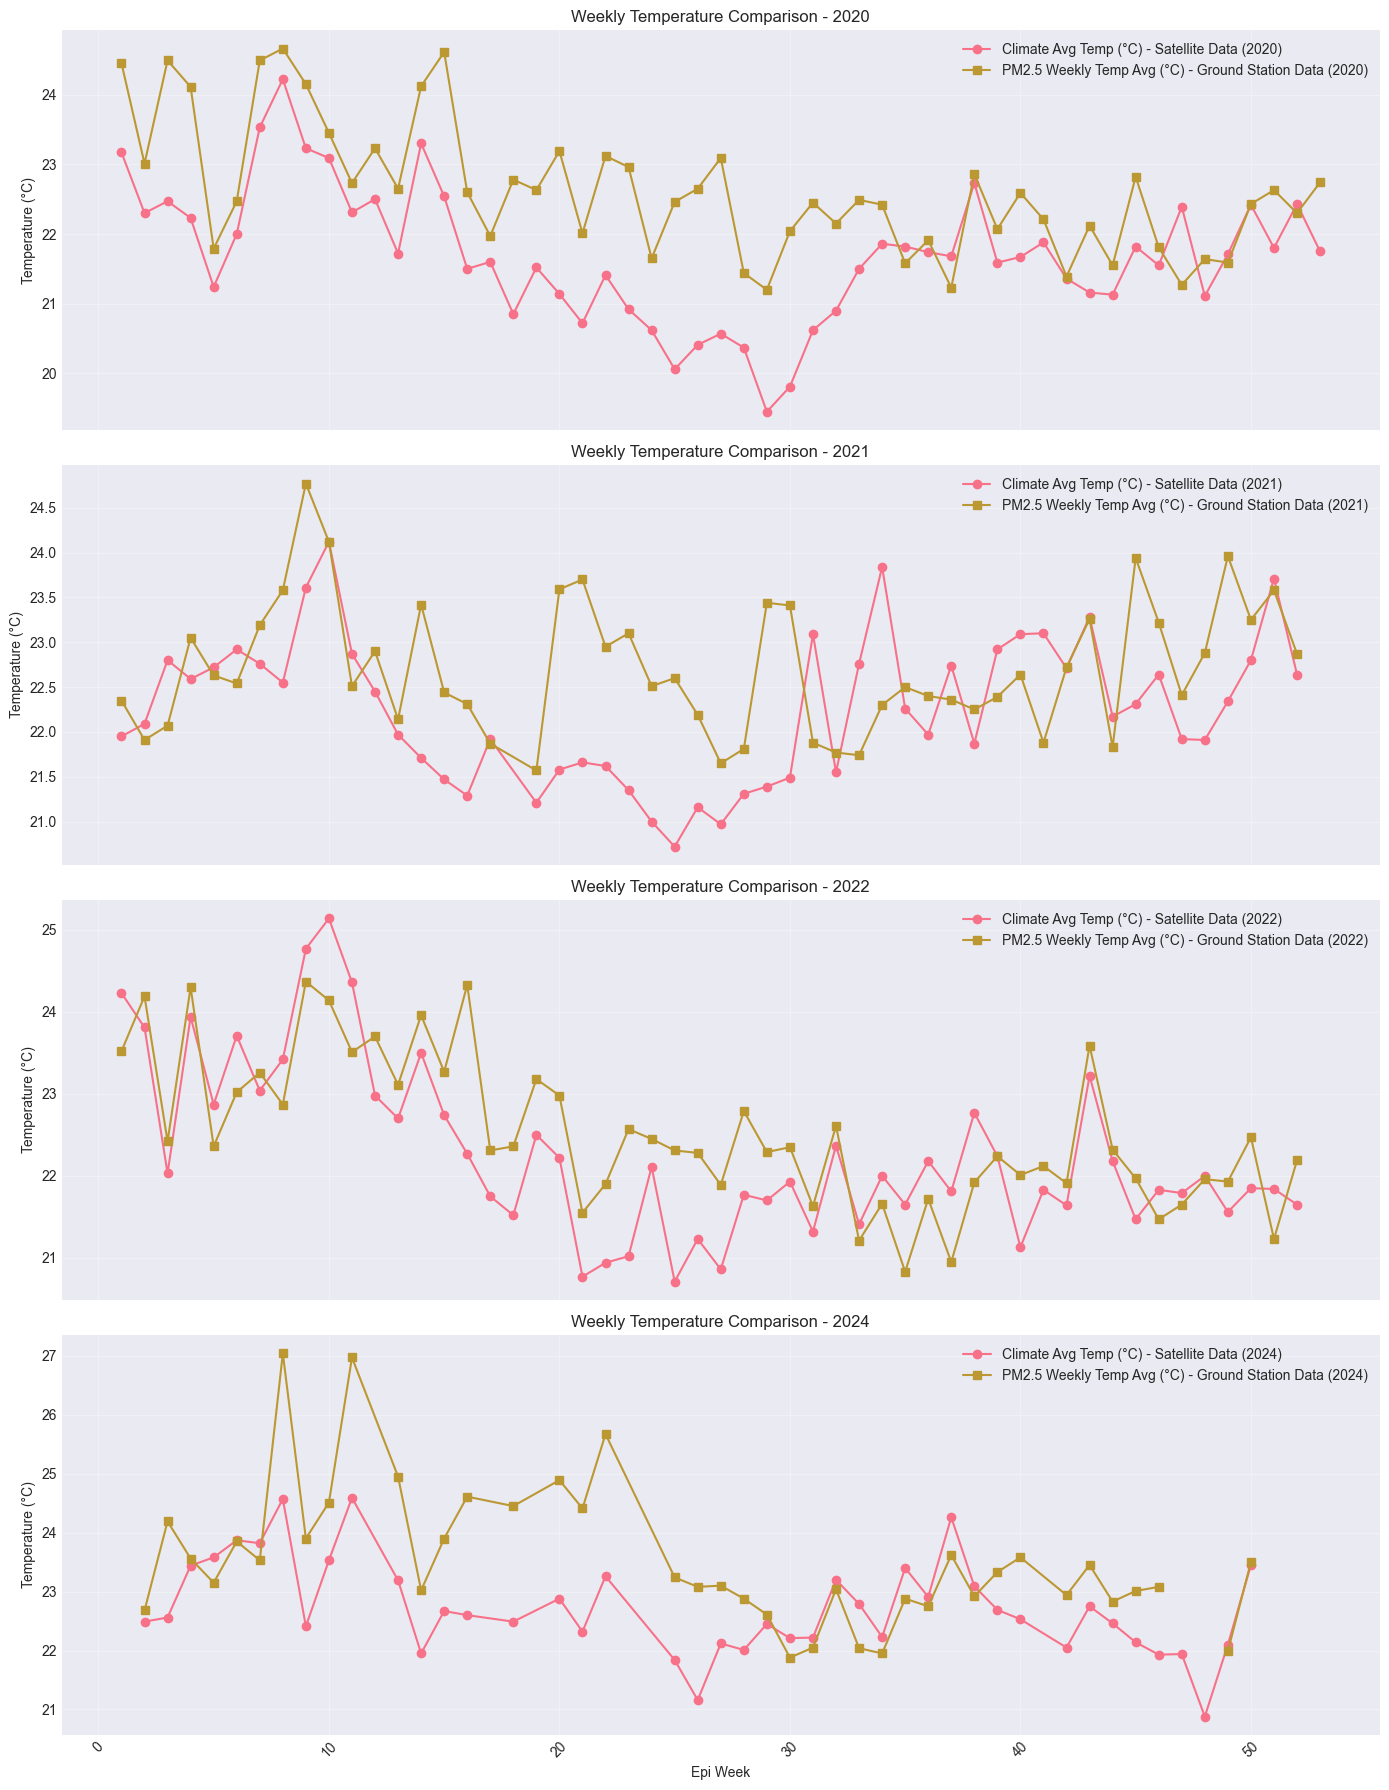

In [45]:
years_to_plot = [2020, 2021, 2022, 2024]

fig, axes = plt.subplots(len(years_to_plot), 1, figsize=(14, 18), sharex=True)

for i, year in enumerate(years_to_plot):
    year_sample_df = main_df[main_df['epi_year'] == year]
    
    axes[i].plot(
        year_sample_df['epi_week'], 
        year_sample_df['Avg_Temp(C)'], 
        marker='o', 
        label=f'Climate Avg Temp (°C) - Satellite Data ({year})'
    )
    
    axes[i].plot(
        year_sample_df['epi_week'], 
        year_sample_df['weekly_temp_avg'], 
        marker='s', 
        label=f'PM2.5 Weekly Temp Avg (°C) - Ground Station Data ({year})'
    )
    
    axes[i].set_title(f'Weekly Temperature Comparison - {year}')
    axes[i].set_ylabel('Temperature (°C)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Shared x-axis label
plt.xlabel('Epi Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [46]:
# ## Step 1: Load and Process Data

# %%
# Initialize data processor
processor = SimplifiedDataProcessor(data_dir='../data')

# Load the merged data
data = processor.load_data('./data/merged_climate_tb_data.csv')
print(f"✓ Loaded data: {len(data)} records")

INFO:simplified_data_processor:SimplifiedDataProcessor initialized with data directory: ..\data
INFO:simplified_data_processor:Loading data from ./data/merged_climate_tb_data.csv
INFO:simplified_data_processor:Loaded 248 records
INFO:simplified_data_processor:Data processing complete: 248 records


✓ Loaded data: 248 records


In [47]:
# Add lag features and rolling averages
processed_data = processor.add_lag_features()
print(f"✓ Added features: {processed_data.shape[1]} total columns")

INFO:simplified_data_processor:Added lag features and rolling averages


✓ Added features: 55 total columns


In [48]:
# Get summary statistics
summary = processor.get_summary_statistics()
print("\nData Summary:")
print(f"- Date range: {summary['date_range']}")
print(f"- Average PM2.5: {summary['pm25_statistics']['mean']:.2f} μg/m³")
print(f"- Total TB cases: {summary['tb_statistics']['total_cases']}")
print(f"- PM2.5-TB correlation: {summary['correlation_pm25_tb']:.3f}")



Data Summary:
- Date range: 2020-01-05 00:00:00 to 2024-12-15 00:00:00
- Average PM2.5: 39.28 μg/m³
- Total TB cases: 158287.77142857143
- PM2.5-TB correlation: -0.017


In [49]:
# Display first few rows
processed_data[['date', 'pm2_5', 'TB', 'avgtemp', 'avghumidity']].head(10)

,date,pm2_5,TB,avgtemp,avghumidity
0,2020-01-05,43.77,7.0,24.45,72.79
1,2020-01-12,68.62,30.0,23.01,75.92
2,2020-01-19,72.99,40.0,24.49,70.07
3,2020-01-26,90.92,37.0,24.11,54.71
4,2020-02-02,35.29,343.0,21.79,83.86
5,2020-02-09,44.04,173.0,22.47,81.82
6,2020-02-16,61.22,302.0,24.49,68.12
7,2020-02-23,40.34,265.0,24.66,76.43
8,2020-03-01,45.60,340.0,24.15,78.90
9,2020-03-08,47.95,338.0,23.45,83.80


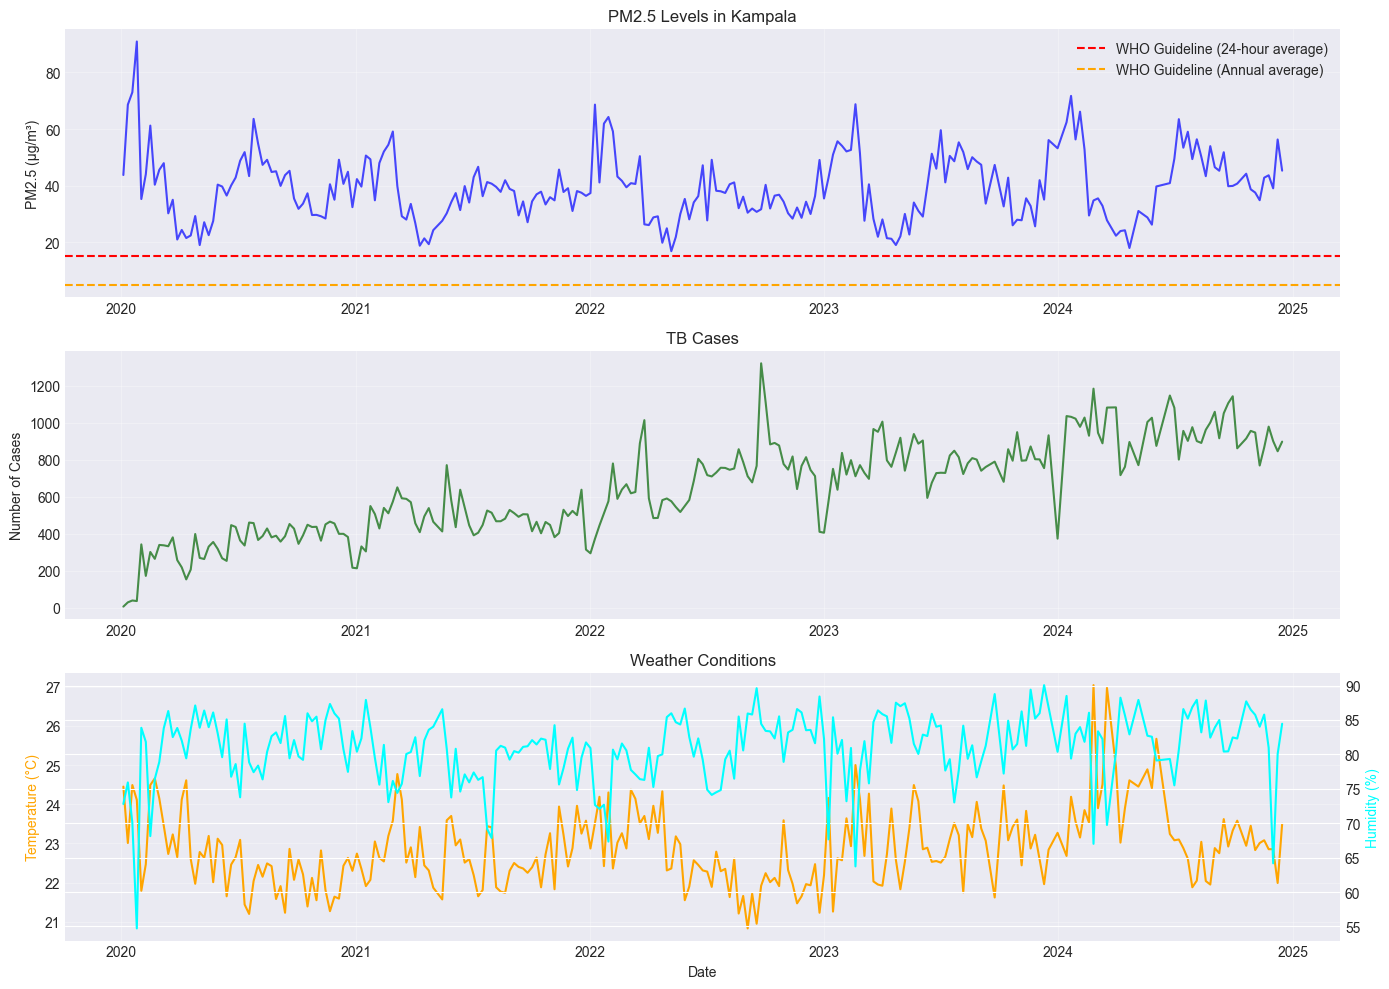

In [50]:
# Time series plot
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# PM2.5 over time
axes[0].plot(data['date'], data['pm2_5'], color='blue', alpha=0.7)
axes[0].axhline(y=15, color='red', linestyle='--', label='WHO Guideline (24-hour average)')
axes[0].axhline(y=5, color='orange', linestyle='--', label='WHO Guideline (Annual average)')

axes[0].set_title('PM2.5 Levels in Kampala')
axes[0].set_ylabel('PM2.5 (μg/m³)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# TB cases over time
axes[1].plot(data['date'], data['TB'], color='darkgreen', alpha=0.7)
axes[1].set_title('TB Cases')
axes[1].set_ylabel('Number of Cases')
axes[1].grid(True, alpha=0.3)

# Temperature and humidity
ax2_twin = axes[2].twinx()
axes[2].plot(data['date'], data['avgtemp'], color='orange', label='Temperature')
ax2_twin.plot(data['date'], data['avghumidity'], color='cyan', label='Humidity')
axes[2].set_title('Weather Conditions')
axes[2].set_ylabel('Temperature (°C)', color='orange')
ax2_twin.set_ylabel('Humidity (%)', color='cyan')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

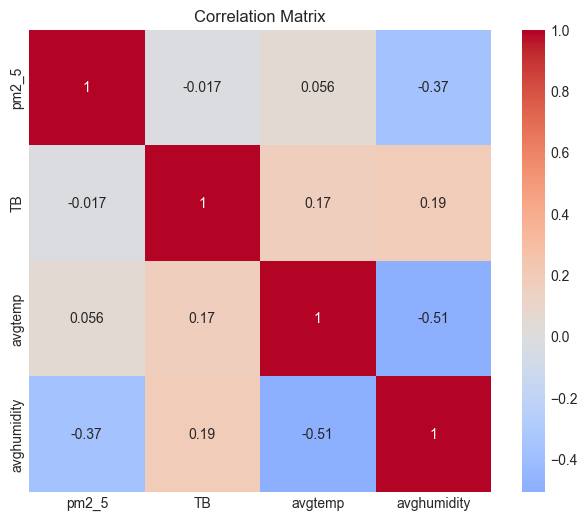

In [52]:
# Correlation analysis
correlation_vars = ['pm2_5', 'TB', 'avgtemp', 'avghumidity']
corr_matrix = data[correlation_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')
plt.show()


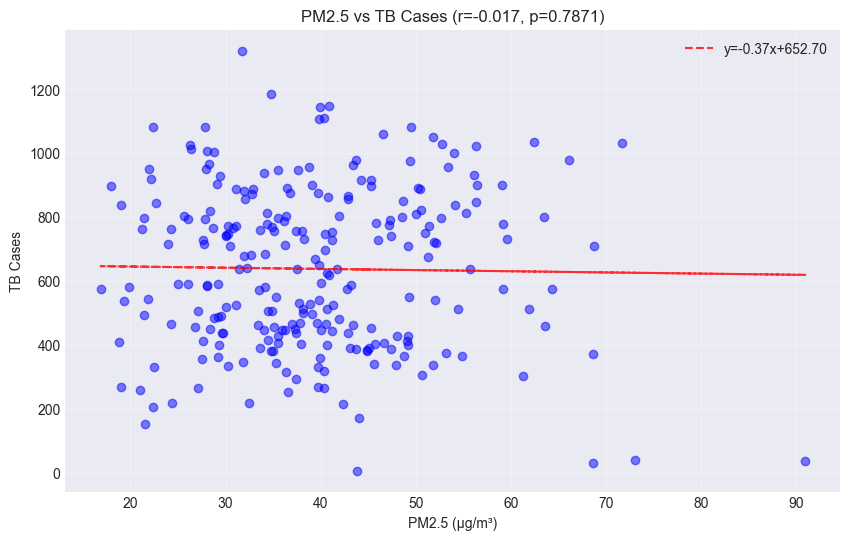

In [56]:
plt.figure(figsize=(10, 6))
plt.scatter(data['pm2_5'], data['TB'], alpha=0.5, color='blue')

# Add regression line
z = np.polyfit(data['pm2_5'], data['TB'], 1)
p = np.poly1d(z)
plt.plot(data['pm2_5'], p(data['pm2_5']), "r--", alpha=0.8, label=f'y={z[0]:.2f}x+{z[1]:.2f}')

# Calculate correlation
corr, p_value = stats.pearsonr(data['pm2_5'], data['TB'])
plt.title(f'PM2.5 vs TB Cases (r={corr:.3f}, p={p_value:.4f})')
plt.xlabel('PM2.5 (μg/m³)')
plt.ylabel('TB Cases')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [57]:
# --- 1. Data Preprocessing ---

# Convert 'date' to datetime and set as index
data_itsa = processed_data.copy()
data_itsa['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y')
data_itsa = data_itsa.sort_values('date').set_index('date')

In [58]:
# --- 2. Handle Missing Data ---

# Check for missing values before handling them
print("--- Missing Values Before Handling ---")
print(data_itsa.isnull().sum())

# Use forward fill to handle missing values, a common method for time series
data_itsa.fillna(value=0, inplace=True)

# Verify that missing values are handled
print("\n--- Missing Values After Forward Fill ---")
print(data.isnull().sum())


--- Missing Values Before Handling ---
epi_year                  0
epi_week                  0
epi_week_label_x          0
avgtemp_sat               0
windspeed                 0
precip                    0
humidity_sat              0
epi_week_label_y          0
pm2_5                     0
avgtemp                   0
avghumidity               0
readings_per_week         0
ILI                       4
ILD_deaths              192
pneumonia_u5              0
pneumonia_u5_deaths      57
SARI                      0
SARI_deaths             134
TB                        0
year_month                0
county                    0
avg_pm2_5_calibrated      0
total_tb                  0
temperature               0
humidity                  0
total_pneumonia           0
pm25_lag_1                1
tb_lag_1                  1
temp_lag_1                1
humidity_lag_1            1
pm25_lag_2                2
tb_lag_2                  2
temp_lag_2                2
humidity_lag_2            2
pm25_lag_

In [59]:
# --- 3. Define the Intervention Point ---

# Find the halfway point in the data
intervention_point = len(data_itsa) // 2
intervention_date = data_itsa.index[intervention_point]

print(f"\nThe dataset has {len(data_itsa)} data points.")
print(f"The intervention is set at index {intervention_point}, which correspondate to the date: {intervention_date.date()}")



The dataset has 248 data points.
The intervention is set at index 124, which correspondate to the date: 2022-05-29


In [60]:
# --- 4. Create Interrupted Time Series (ITS) Variables ---

# Time variable: a sequence from 1 to the number of observations
data_itsa['time'] = np.arange(1, len(data_itsa) + 1)

# Intervention variable: 0 before the intervention, 1 after
data_itsa['intervention'] = (data_itsa.index >= intervention_date).astype(int)

# Time since intervention: 0 before, and counts up from 1 after the intervention
data_itsa['time_since_intervention'] = 0
post_intervention_indices = data_itsa[data_itsa['intervention'] == 1].index
time_since_intervention_values = np.arange(len(post_intervention_indices))
data_itsa.loc[post_intervention_indices, 'time_since_intervention'] = time_since_intervention_values

In [61]:
# --- 5. Model Building ---

# Define dependent and independent variables
y = data_itsa['TB']
X = data_itsa[['time', 'intervention', 'time_since_intervention', 'pm2_5', 'avgtemp', 'avghumidity']]
X = sm.add_constant(X) # Add a constant (intercept) to the model

# Fit the Ordinary Least Squares (OLS) model
model = sm.OLS(y, X).fit()

# Print the model summary
print("\n--- Interrupted Time Series Model Summary ---")
print(model.summary())


--- Interrupted Time Series Model Summary ---
                            OLS Regression Results                            
Dep. Variable:                     TB   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     131.6
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           4.09e-73
Time:                        15:39:27   Log-Likelihood:                -1542.3
No. Observations:                 248   AIC:                             3099.
Df Residuals:                     241   BIC:                             3123.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [62]:
# Make sure the index is datetime
data_itsa.index = pd.to_datetime(data_itsa.index, errors='coerce')

# Add a year column from the index
data_itsa['year'] = data_itsa.index.year
years = sorted(data_itsa['year'].unique())


KeyError: 'predicted_tb'

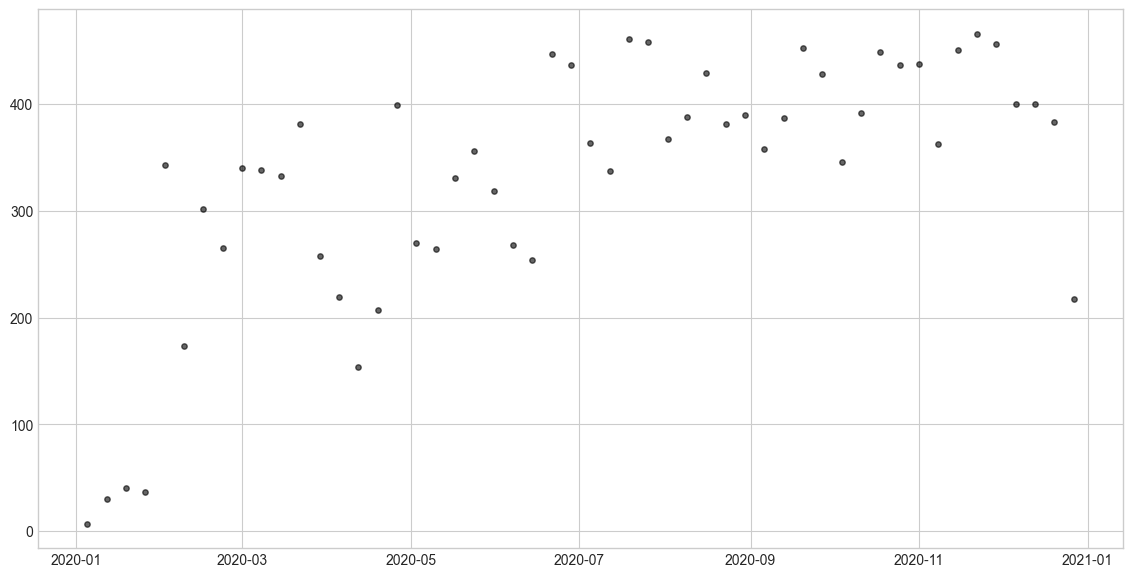

In [63]:
plt.style.use('seaborn-v0_8-whitegrid')

for year in years:
    year_df = data_itsa[data_itsa['year'] == year]
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Observed TB cases
    ax.scatter(year_df.index, year_df['TB'], color='black', alpha=0.6, label='Observed TB Cases', s=15)
    
    # Pre-intervention trend
    pre_data = year_df[year_df['intervention'] == 0]
    ax.plot(pre_data.index, pre_data['predicted_tb'], color='blue', linewidth=2, label='Pre-intervention Trend')
    
    # Post-intervention trend
    post_data = year_df[year_df['intervention'] == 1]
    ax.plot(post_data.index, post_data['predicted_tb'], color='red', linewidth=2, label='Post-intervention Trend')
    
    # Counterfactual
    ax.plot(post_data.index, post_data['counterfactual_tb'], color='green', linestyle='--', linewidth=2, label='Counterfactual (No Intervention)')
    
    # Intervention marker (only if it falls within this year)
    if intervention_date.year == year:
        ax.axvline(x=intervention_date, color='purple', linestyle=':', linewidth=2.5, label=f'Intervention: {intervention_date.date()}')
    
    # Formatting
    ax.set_title(f'ITS Analysis of TB Cases - {year}', fontsize=18, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Number of TB Cases', fontsize=12)
    ax.legend(loc='upper left', fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


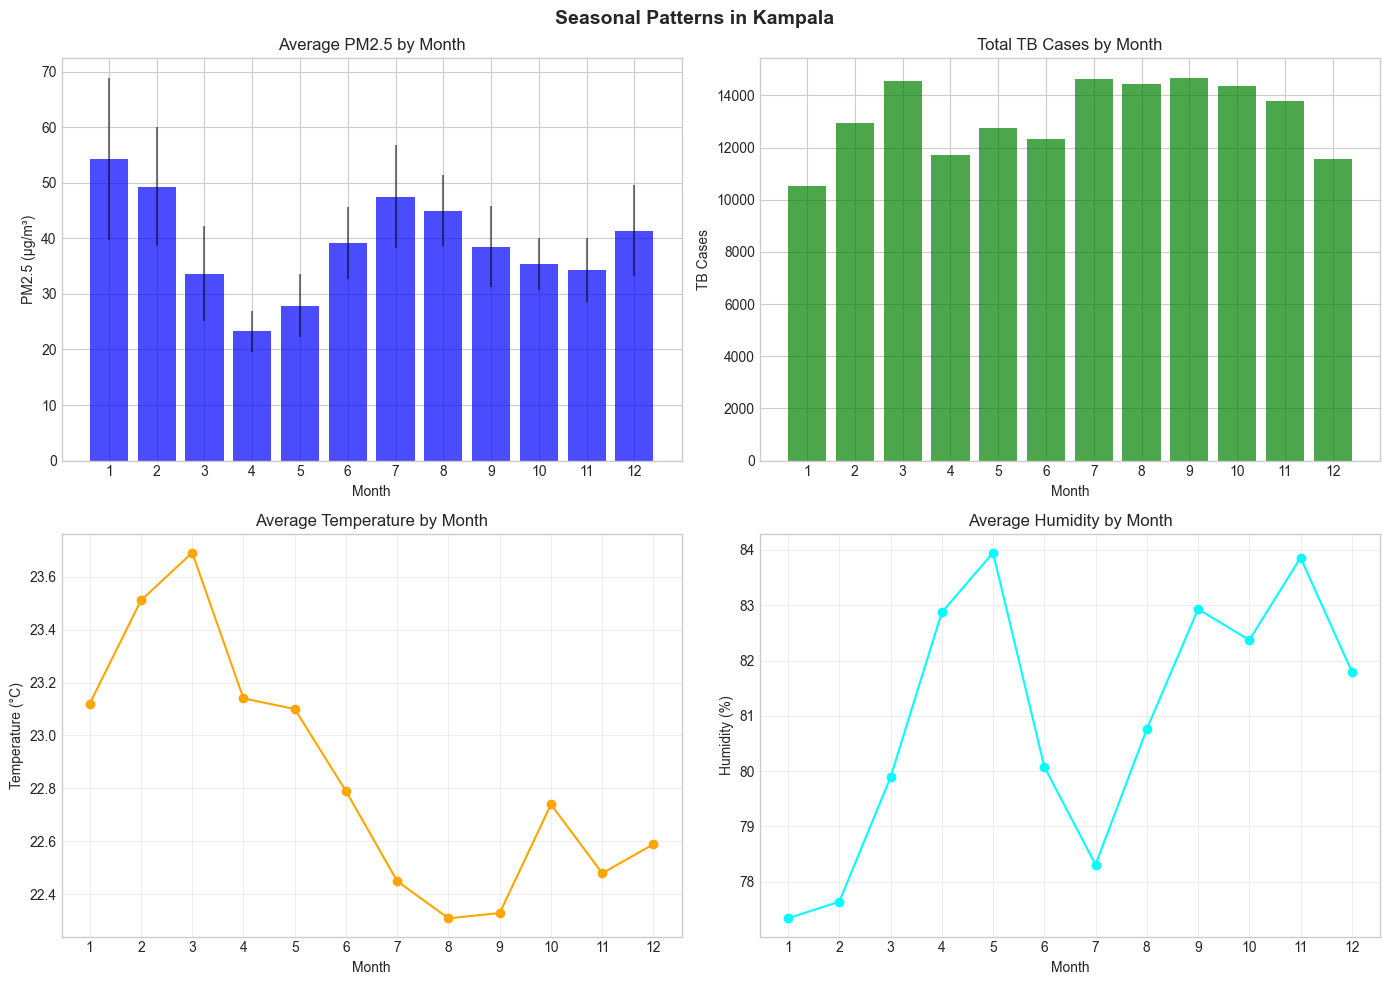

In [ ]:

# Monthly patterns
data['month'] = data['date'].dt.month
monthly_stats = data.groupby('month').agg({
    'pm2_5': ['mean', 'std'],
    'TB': ['mean', 'sum'],
    'avgtemp': 'mean',
    'avghumidity': 'mean'
}).round(2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PM2.5 by month
axes[0, 0].bar(range(1, 13), monthly_stats['pm2_5']['mean'].values, color='blue', alpha=0.7)
axes[0, 0].errorbar(range(1, 13), monthly_stats['pm2_5']['mean'].values, 
                     yerr=monthly_stats['pm2_5']['std'].values, fmt='none', color='black', alpha=0.5)
axes[0, 0].set_title('Average PM2.5 by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
axes[0, 0].set_xticks(range(1, 13))

# TB cases by month
axes[0, 1].bar(range(1, 13), monthly_stats['TB']['sum'].values, color='green', alpha=0.7)
axes[0, 1].set_title('Total TB Cases by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('TB Cases')
axes[0, 1].set_xticks(range(1, 13))

# Temperature pattern
axes[1, 0].plot(range(1, 13), monthly_stats['avgtemp']['mean'].values, 'o-', color='orange')
axes[1, 0].set_title('Average Temperature by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Temperature (°C)')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].grid(True, alpha=0.3)

# Humidity pattern
axes[1, 1].plot(range(1, 13), monthly_stats['avghumidity']['mean'].values, 'o-', color='cyan')
axes[1, 1].set_title('Average Humidity by Month')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Humidity (%)')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Seasonal Patterns in Kampala', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [52]:
data_project = processed_data.copy()
data_project = data_project[["date", "TB"]]
data_project = data_project.rename(columns={"TB": "y"})
data_project['date'] = pd.to_datetime(data_project['date'], format='%d/%m/%Y')